# InspiraSTEM Día 2 - Modelado y Análisis de Espectros Moleculares

### 20 septiembre 2026

Comenzamos de nuevo clonando el repositorio de GitHub y cambiando al directorio correspondiente para facilitar la importación en la siguiente celda.

In [ ]:
## !git clone https://github.com/mas-astro/inspirastem-ppd-CO

## %cd /content/inspirastem-ppd-CO

In [ ]:
# AVISO: Al ejecutar esta celda, es posible que aparezca
# un mensaje pidiéndote que reinicies la sesión. Esto es
# normal y podrás volver a ejecutar las celdas.

## !pip install -r 00_antecurso/requisitos.txt
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")

print('¡Listo! Has importado correctamente las bibliotecas.')

¡Listo! Has importado correctamente las bibliotecas.


In [ ]:
import specutils
import numpy as np
import pandas as pd
import statistics as st
import scipy

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import LogNorm
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import AutoMinorLocator

from astropy.io import fits
from astropy import units as u
from astropy import constants as const
from astropy.visualization import quantity_support
quantity_support()
import astropy.utils.compat
from astropy.modeling import models
from astropy.nddata import StdDevUncertainty

from specutils import Spectrum1D
from specutils.analysis import line_flux
from specutils import Spectrum1D, SpectralRegion
from specutils.manipulation import extract_region
from specutils.fitting import fit_generic_continuum

from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans

En los siguientes dos celdas, configuramos nuestros datos y las tablas de datos para poder acceder a ellos más fácilmente más adelante en el script.

Instrucciones: Corre la celda y encuentra el índice de tu disco (0-15) según el disco que hayas seleccionado. Por ejemplo, **AA Tau = 1**. Por lo tanto, más adelante en el código, usarás este identificador para referirte a tu disco.

Avisa si hay alguna problema.

In [11]:
######################################### preparando archivos ####################################################
import os
import pandas as pd
import numpy as np
from astropy.io import fits
from astropy import units as u
from astropy import constants as const
from astropy.nddata import StdDevUncertainty
from specutils import Spectrum1D

# Determinamos la ruta base de los datos de forma flexible (funciona en Colab y localmente)
if os.path.exists('data'):
    base_data_path = 'data'
elif os.path.exists('../data'):
    base_data_path = '../data'
elif os.path.exists('/content/inspirastem-ppd-CO/data'):
    base_data_path = '/content/inspirastem-ppd-CO/data'
else:
    base_data_path = 'data'

c_u = (const.c.value *1e6) *(u.micron/u.s)   # units = [um/s]
CO_lines = os.path.join(base_data_path, 'HITRAN_CO_lineas.xlsx')
COlines_table = pd.read_excel(CO_lines, sheet_name="COlineranges")

# El nombre del archivo FITS de tu disco aqui.
# AA Tau esta usado como ejemplo:
nom_disco = os.path.join(base_data_path, 'discos/AATau_M.fits')
nom_per_apil = os.path.join(base_data_path, 'lineas_apiladas/AATau_COv1-0stacked.fits')

flhead = ['RULup_M_APR07', 'AATau_M','CVCha_M','DFTAU_M','DoAr44_M_SEP07','DRTau_M_DEC08','EXLup14_M','HD135344B_M_APR07',
          'HD142527_M_5AUG08','HD144432S_M','TWHya_M','RYLup_M_APR07','HD36112_ISHELL','TWCha_M_JAN09','HD139614_Carmona',
          'HD31293_ISHELL','HD31648_ISHELL']
errhead = ['RULup_M_APR07_err','AATau_M_err','CVCha_M_err','DFTAU_M_err','DoAr44_M_SEP07_err','DRTau_M_DEC08_err',
           'EXLup14_M_err','HD135344B_M_APR07_err','HD142527_M_5AUG08_err','HD144432S_M_err','TWHya_M_err',
           'RYLup_M_APR07_err','HD36112_ISHELL_err','TWCha_M_JAN09_err','HD139614_Carmona_err','HD31293_ISHELL_err',
           'HD31648_ISHELL_err']

heads = flhead + errhead

########################################## abriendo archivos ####################################################

still = os.path.join(base_data_path, '')
ffile = [
        [still + 'discos/RULup_M_APR07.fits',     #     [ 0 ]
         still + 'discos/AATau_M.fits',           #     [ 1 ]
         still + 'discos/CVCha_M.fits',           #     [ 2 ]
         still + 'discos/DFTAU_M.fits',           #     [ 3 ]
         still + 'discos/DoAr44_M_SEP07.fits',    #     [ 4 ]
         still + 'discos/DRTau_M_DEC08.fits',     #     [ 5 ]
         still + 'discos/EXLup14_M.fits',         #     [ 6 ]
         still + 'discos/HD135344B_M_APR07.fits', #     [ 7 ]
         still + 'discos/HD142527_M_5AUG08.fits', #     [ 8 ]
         still + 'discos/HD144432S_M.fits',       #     [ 9 ]
         still + 'discos/TWHya_M.fits',           #    [ 10 ]
         still + 'discos/RYLup_M_APR07.fits',     #    [ 11 ]
         still + 'discos/HD36112_ISHELL.fits',    #    [ 12 ]
         still + 'discos/TWCha_M_JAN09.fits',     #    [ 13 ]
         still + 'discos/HD139614_Carmona.fits',  #    [ 14 ]
         still + 'discos/HD31293_ISHELL.fits',    #    [ 15 ]
         still + 'discos/HD31648_ISHELL.fits'],   #    [ 16 ]

        [still + 'lineas_apiladas/RULup_COv1-0stacked.fits',     #     [ 0 ]
         still + 'lineas_apiladas/AATau_COv1-0stacked.fits',     #     [ 1 ]
         still + 'lineas_apiladas/CVCha_COv1-0stacked.fits',     #     [ 2 ]
         still + 'lineas_apiladas/DFTAU_COv1-0stacked.fits',     #     [ 3 ]
         still + 'lineas_apiladas/DoAr44_COv1-0stacked.fits',    #     [ 4 ]
         still + 'lineas_apiladas/DRTau_COv1-0stacked.fits',     #     [ 5 ]
         still + 'lineas_apiladas/EXLup14_COv1-0stacked.fits',   #     [ 6 ]
         still + 'lineas_apiladas/HD135344B_COv1-0stacked.fits', #     [ 7 ]
         still + 'lineas_apiladas/HD142527_COv1-0stacked.fits',  #     [ 8 ]
         still + 'lineas_apiladas/HD144432S_COv1-0stacked.fits', #     [ 9 ]
         still + 'lineas_apiladas/TWHya_COv1-0stacked.fits',     #    [ 10 ]
         still + 'lineas_apiladas/RYLup_COv1-0stacked.fits',     #    [ 11 ]
         still + 'lineas_apiladas/HD36112_COv1-0stacked.fits',   #    [ 12 ]
         still + 'lineas_apiladas/TWCha_COv1-0stacked.fits',     #    [ 13 ]
         still + 'lineas_apiladas/HD139614_COv1-0stacked.fits',  #    [ 14 ]
         still + 'lineas_apiladas/HD31293_COv1-0stacked.fits',    #    [ 15 ]
         still + 'lineas_apiladas/HD31648_COv1-0stacked.fits']    #    [ 16 ]
        ]

COv = COlines_table['vib']
COb = COlines_table['branch']
coo = np.where( (COv=='v1-0') & (COb=='P') )
P   = coo[0]
COl = COlines_table['line'][P].reset_index()['line']
COw = COlines_table['wl'][P].reset_index()['wl']

fluxdf = pd.DataFrame(columns=heads, index=COl)
for y in range(len(heads)):
    fluxdf[heads[y]] = np.repeat(0., len(P))

print("Ejecutó con éxito la célula")

Ejecutó con éxito la célula


In [12]:
###### from astropy.modeling.polynomial import Chebyshev1D
from specutils.fitting import fit_lines
from matplotlib.backends.backend_pdf import PdfPages
from specutils.analysis import fwzi
from scipy.signal import find_peaks, peak_widths
import datetime
from pandas import ExcelWriter


win  = 5.2e-4       # range within continuum values will be measured/fitted
cont = 1.95e-3      # distance from central line at which 'win' will begin
diskinds = []         # Stores the indexes used per disk.
chi_table = []      # Stores scale & chi^2
specRes = [[],[]]
#mp_fwzi = pd.ExcelWriter(datetime.datetime.now().strftime("%b"+"%d")+'_model_input.xlsx', engine='xlsxwriter')
writer = pd.ExcelWriter('inspirastem_test_CO.xlsx')#, engine='xlsxwriter')
#pdf_disks = PdfPages('2020-05-22 Pline_v_Flux.pdf')
#pdf_spectra = PdfPages('2020-05-22 Disk Spectra.pdf')

# Funciones (*información*)

 ## wave2vel():
 - entrada: ancho de línea de longitud de onda EN MICRAS
 - salida: ancho de línea de velocidad EN KM/S

## vel2wav():
 - entrada: ancho de línea de velocidad EN KM/S
 - salida: ancho de línea de longitud de onda EN MICRAS

## best_fit1d():
 Esta función fue diseñada para objetos Spectrum1D()
  - debe optimizarse para un enfoque más general

Instrucciones:
Corren la celda normal.


In [13]:
###############################################################################################################
def wav2vel(LINE_WIDTH, REST_WAVELENGTH, LINE_VELOCITY_WIDTH=None): # vel in km/s, wv in um
    velocity = ((LINE_WIDTH/REST_WAVELENGTH)-1)*const.c.value*1e-3 # converting data wv to vel. then resampled
    if LINE_VELOCITY_WIDTH is not None:
        vel_mask = (min(LINE_VELOCITY_WIDTH)<velocity)&(velocity<max(LINE_VELOCITY_WIDTH))
        velos = velocity[vel_mask]
        return velocity, vel_mask, velos
    elif LINE_VELOCITY_WIDTH is None:
        return velocity
###############################################################################################################
def vel2wav(LINE_VELOCITY_WIDTH, REST_WAVELENGTH, LINE_WIDTH=None): # vel in km/s, wv in um
    st_wav = ((LINE_VELOCITY_WIDTH/(const.c.value*1e-3))+1)*REST_WAVELENGTH
    if LINE_WIDTH is not None:
        m_mask = (min(st_wav)<LINE_WIDTH)&(LINE_WIDTH<max(st_wav))
        return st_wav, m_mask, st_wav[m_mask[0]]
    elif LINE_WIDTH is None:
        return st_wav
###############################################################################################################
def best_fit1d(LINE_FLUX_DENSITY, CONT_FIT, RESAMPLED_WV, FLUX_ERROR):#, SUBSPEC1D_OBJ):
    scale = np.arange(0,2.75,0.01)
    chi_list = []
    for l in scale:
        chi_2 = np.nansum(((LINE_FLUX_DENSITY-CONT_FIT)-(l*RESAMPLED_WV))**2*
                          (FLUX_ERROR**(-2)) )
        chi_list.append(chi_2)
    min_chi = chi_list[np.where(min(chi_list)==chi_list)[0][0]]
    bestmodelfluxes = scale[np.where(min(chi_list)==chi_list)[0][0]] * RESAMPLED_WV
    scale_chi.append([scale[0],chi_list])
    #bestmodelspectra = Spectrum1D(flux=(bestmodelfluxes+CONT_FIT[MOD_MASK])*u.Jy,
    #                    spectral_axis=SUBSPEC1D_OBJ.spectral_axis[MOD_MASK])
    return bestmodelfluxes, chi_list, scale_chi#, bestmodelspectra
###############################################################################################################
def line_profile(master_s1d, dat_wav,dat_flux,l_bound,r_bound,left_line,right_line): # master_s1d = Spectrum1D()
    line_ind = np.where(np.logical_and(master_s1d.spectral_axis.value>=l_bound,
                                        master_s1d.spectral_axis.value<=r_bound))
    line_mask = (master_s1d.spectral_axis > left_line*u.micron)&(master_s1d.spectral_axis <
                                                                    right_line*u.micron)
    #datline_mask = (dat_wav[pline_ind] > left_line) & (dat_wav[pline_ind] < right_line)
    wav_pind = dat_wav[line_ind]
    flux_pind = dat_flux[line_ind]
    #sub_ms1d = Spectrum1D(flux=master_s1d.flux[pline_ind], spectral_axis=master_s1d.spectral_axis[pline_ind],
    #                     uncertainty=master_s1d.uncertainty[pline_ind])
    return line_mask, wav_pind, flux_pind, line_ind #datline_mask, sub_ms1d,
###############################################################################################################
def continuum_fit(SUB_SPECTRUM1D, CONT_MASK, SPEC_UNCERT):
    p_fit = np.polyfit(SUB_SPECTRUM1D.spectral_axis.value[CONT_MASK],
                       SUB_SPECTRUM1D.flux.value[CONT_MASK], deg=1, w=(SPEC_UNCERT[CONT_MASK])**(-2),
                       cov='unscaled') # cov=unscaled means our uncertainties are reliable.
    a_err = np.sqrt(np.diag(p_fit[1])[1]) # stdev a
    b_err = np.sqrt(np.diag(p_fit[1])[0]) # stdev b
    y_cont_fit = (p_fit[0][0]*sub_spec.spectral_axis.value) + p_fit[0][1] # y=bx+a Continuum Fit
    cont_err = np.sqrt((a_err**2) + (sub_spec.spectral_axis.value*(b_err))**2) # Jansky
    return y_cont_fit, cont_err
###############################################################################################################

# Mostrar Lineas
## Protocolo para eligir lineas en un disco y mostrarlas uno por uno.

Instrucciones: Encuentra tu disco y el número que le pertenece. Ese número debe irse donde está `d_i = (número del disco)`. Se pueden ver otros discos y líneas si desean. Mas abajo, puedes cambiar cual línea quieres ver andonde dice `index = `.

../data/discos/AATau_M.fits
0.0001
0 P1
1 P2
2 P3
3 P4
4 P5
5 P6
6 P7
7 P8
8 P9
9 P10
10 P11
11 P12
12 P13
13 P14
14 P15
15 P16
16 P17
['P6']


(0.9, 1.95)

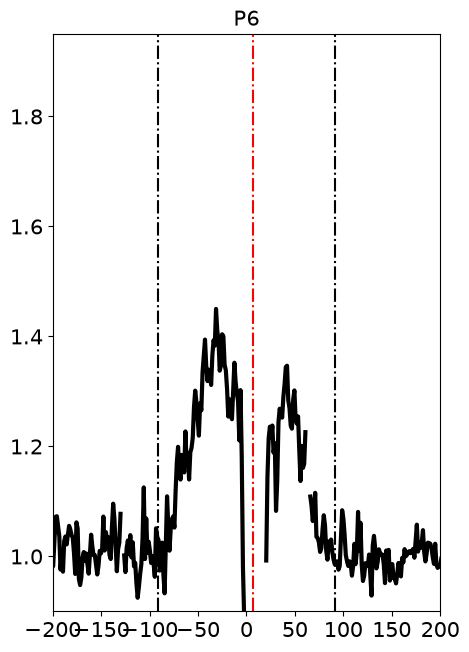

In [14]:
# 0 - RU Lupi     # 6 - EX Lupi      # 12 - HD36112
# 1 - AA Tauri    # 7 - HD135344B    # 13 - TW Cha
# 2 - CV Cha      # 8 - HD142527     # 14 - HD139614
# 3 - DF Tauri    # 9 - HD144432S    # 15 - HD31293
# 4  - DO Ar44    # 10 - TW Hydrae   # 16 - HD31648
# 5  - DR Tauri   # 11 - RY Lupi

d_i = 1

limit_lines = os.path.join(base_data_path, 'limites_linea_disco.xlsx')

flux_df = pd.read_excel(limit_lines, sheet_name=flhead[d_i])
df_line = flux_df['line'].to_numpy()
rest_wav = flux_df['wavelength'].to_numpy()
lam_min = flux_df['lammin'].to_numpy()
lam_max = flux_df['lammax'].to_numpy()
line_flux = flux_df['flux'].to_numpy()
print(ffile[0][d_i])

############     Velocity Shift per disk
offset = pd.read_excel(limit_lines, sheet_name='Disk Res')['offset'].to_numpy()[d_i]
COw_n = COw.to_numpy()
COl_n = COl.to_numpy()

############    CO SPECTRAL DATA: (um,Jy)
specdata = fits.open(ffile[0][d_i])[1].data[0]
fits.open(ffile[0][d_i]).close()
wv  = specdata[0]*1e-3
fln = specdata[1]
err = StdDevUncertainty(specdata[2], unit = 'Jy')
m_spec = Spectrum1D(flux=fln*u.Jy, spectral_axis=wv*u.micron, uncertainty=err)

############    STACKED LINE PROFILE (ks/s, um, Jy)
stackdata = fits.open(ffile[1][d_i])[1].data[0]
fits.open(ffile[1][d_i]).close()
vel = stackdata[0]
flx = stackdata[1]
errr = stackdata[2]
yfitt = stackdata[3]

v_d = pd.read_excel(limit_lines, sheet_name='Disk Res')
v_shift = v_d['offset'][d_i]
print(v_shift)

index = 5
for dex in flux_df.index[0:]:
    print(dex, COl_n[dex])

lll = np.where(df_line[index] == COl_n)[0]
st_wav = vel2wav(vel,COw_n[lll])
print(COl_n[lll])

v_wav = wav2vel(wv - v_shift, COw_n[lll])
vel_min = wav2vel(lam_min[index],COw_n[lll])
vel_max = wav2vel(lam_max[index],COw_n[lll])
v_offset = wav2vel(COw_n[lll]+offset,COw_n[lll])

ghost = plt.figure(figsize=(5,7.5))
plt.plot(v_wav, fln, linewidth=3.0, color='black')
plt.title(COl_n[index], fontsize=15)
plt.axvline(v_offset, color='red', linestyle='-.')
plt.axvline(vel_min, color='black', linestyle='-.')
plt.axvline(vel_max, color='black', linestyle='-.')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(-200, 200)
plt.ylim(.9,1.95)

# LTE Single-Slab Model

Instrucciones:
1. Cambia `fi` por el número que corresponda a tu disco.
2. Modifica los parámetros del modelo para ajustar la excitación del modelo y, por lo tanto, su forma.
3. Te recomiendo cambiar un parámetro a la vez y observar qué cambios se producen con cada aumento o disminución de la temperatura `temp`, la densidad de columna`n_mol` o el área emisora `area`.
4. Toma nota de esos cambios para que podamos discutirlos.

In [15]:
import sys
import os
proj_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)
if '/content/inspirastem-ppd-CO/' not in sys.path:
    sys.path.append('/content/inspirastem-ppd-CO/')

from ir_model_ms import *
from scipy.optimize import fmin
import openpyxl
try:
    from herramientas import readspecs as rs
except ImportError:
    rs = None

mol_data = MolData("CO", os.path.join(base_data_path, "co_hitran12.par"))
intensity = Intensity(mol_data)
mp = limit_lines

fi = 12 # numero de disco
fitsfi = os.path.join(base_data_path, 'discos', flhead[fi]+'.fits')
mp_fi = pd.read_excel(mp, sheet_name=flhead[fi])
ch = pd.read_excel(mp, sheet_name='Disk Res')
Rk = ch.loc[fi,'R_tot']
n_el = len(mp_fi['flux'])
dof = 3
RC = Rk

# Parametros del modelo
temp  = 100
n_mol = 1e15
radio = 3

# calcular intensidad
intensity.calc_intensity(t_kin=temp, n_mol=n_mol, dv=1.0)

# crear espectrum
test__spectrum = Spectrum(lam_min=4.2, lam_max=5.3, dlambda=0.00002, R=RC, distance=140.0)
test__spectrum.add_intensity(intensity, radio**2 * np.pi)

print('Resolución Espectral =', Rk)
print(fi, flhead[fi])

Resolución Espectral = 22975.21718301487
12 HD36112_ISHELL


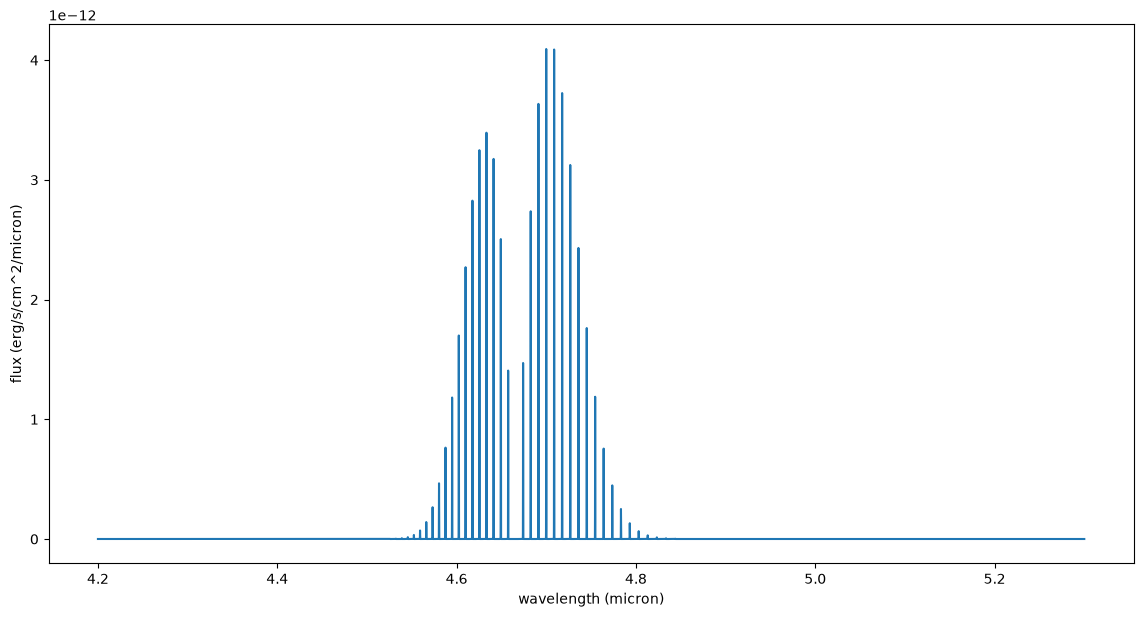

In [16]:
plt.figure(figsize=(14, 7))
plt.plot(test__spectrum.lamgrid, test__spectrum.flux_jy)
plt.xlabel("wavelength (micron)")
plt.ylabel("flux (erg/s/cm^2/micron)");